# Objective

## Dhaka regularly ranks among the most polluted cities in the world, and fine particulate matter (PM2.5) is the pollutant most closely linked to serious health risks for its residents. The objective of this project is to build a time series model that forecasts hourly PM2.5 concentrations in Dhaka for the next 24 to 72 hours, using recent air quality data and meteorological variables (temperature, humidity, wind speed, and precipitation) from the Open-Meteo APIs. The workflow covers data collection, cleaning, and exploratory analysis of daily and seasonal patterns, followed by a comparison of a seasonal naive baseline against statistical models (SARIMA, Prophet) and machine learning models (XGBoost, LightGBM) with lag and weather features. Models are evaluated with rolling-origin validation to avoid data leakage, and the best one is deployed as a live Streamlit app that refreshes automatically with the latest data, so anyone can see the current air quality and the upcoming forecast.

# Import Necessary Libraries

In [11]:
# Data collection and handling
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Time series analysis and statistical models
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Machine learning models and validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Saving the model for deployment
import joblib


# API feasibility Test

In [2]:


# Define the API URL
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": 23.81,
    "longitude": 90.41,
    "hourly": "pm2_5,pm10",
    "start_date": "2022-10-01",
    "end_date": "2026-10-03",
    "timezone": "Asia/Dhaka",
}

# Fetch data from the API
response = requests.get(url, params=params, timeout=60)
response.raise_for_status()
data = response.json()



# Build DataFrame

In [9]:
hourly_data = data["hourly"]
df = pd.DataFrame({
    "time": hourly_data["time"],
    "pm2_5": hourly_data["pm2_5"],
    "pm10": hourly_data["pm10"],
})
df.head()
df.to_csv("air_ql.csv")

## Set data formats

In [12]:
df=pd.read_csv("air_ql.csv")
df['time']=pd.to_datetime(df["time"])
df=df.set_index('time')
# Basic checks
print(df.shape)
print(df.index.min(), "->", df.index.max())
print("Frequency:", pd.infer_freq(df.index))
print("Null Values",df.isna().sum())
print(df.describe())

(35136, 3)
2022-10-01 00:00:00 -> 2026-10-03 23:00:00
Frequency: h
Null Values Unnamed: 0    0
pm2_5         0
pm10          0
dtype: int64
         Unnamed: 0         pm2_5          pm10
count  35136.000000  35136.000000  35136.000000
mean   17567.500000     48.292321     62.421681
std    10143.033866     34.259600     43.266144
min        0.000000      0.400000      0.500000
25%     8783.750000     22.100000     28.200000
50%    17567.500000     40.900000     54.600000
75%    26351.250000     66.100000     85.900000
max    35135.000000    309.200000    394.900000


# Explore the Dataset

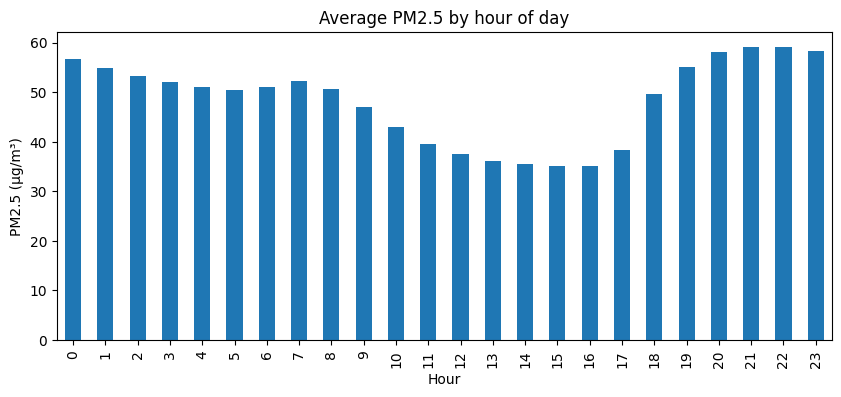

In [6]:
# 5. Average PM2.5 by hour of day
hourly_avg = df.groupby(df.index.hour)["pm2_5"].mean()
hourly_avg.plot(kind="bar", figsize=(10, 4), title="Average PM2.5 by hour of day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

# Check the time window 

In [7]:
def window(h):
    if 5 <= h < 8:   return "Morning"
    if 8 <= h < 11:  return "Office peak"
    if 16 <= h < 20: return "Afternoon peak"
    if h >= 21 or h < 5: return "Night"
    return "Other"

df["window"] = df.index.hour.map(window)
print(df.groupby("window")["pm2_5"].agg(["mean", "std"]))

                     mean        std
window                              
Afternoon peak  44.535178  26.457786
Morning         51.212933  39.711971
Night           55.570261  38.509977
Office peak     46.912546  36.450536
Other           40.322746  25.490368


In [13]:
# Monthly resample
print(df["pm2_5"].resample("MS").mean().round(1))

time
2022-10-01     40.4
2022-11-01     58.6
2022-12-01     73.3
2023-01-01     99.3
2023-02-01     69.8
2023-03-01     61.4
2023-04-01     55.8
2023-05-01     44.5
2023-06-01     31.7
2023-07-01     14.0
2023-08-01     32.4
2023-09-01     25.5
2023-10-01     45.4
2023-11-01     47.2
2023-12-01     48.2
2024-01-01     69.4
2024-02-01     65.7
2024-03-01     55.3
2024-04-01     45.6
2024-05-01     37.6
2024-06-01     29.4
2024-07-01     15.0
2024-08-01     15.4
2024-09-01     25.9
2024-10-01     47.8
2024-11-01     69.3
2024-12-01     83.0
2025-01-01    103.2
2025-02-01     95.9
2025-03-01     60.1
2025-04-01     40.7
2025-05-01     35.9
2025-06-01     28.5
2025-07-01     21.3
2025-08-01     20.7
2025-09-01     27.9
2025-10-01     47.2
2025-11-01     59.0
2025-12-01     68.2
2026-01-01     90.3
2026-02-01     78.1
2026-03-01     63.4
2026-04-01     38.8
2026-05-01     38.3
2026-06-01     35.3
2026-07-01     17.8
2026-08-01     15.8
2026-09-01     29.2
2026-10-01     73.7
Freq: MS, Name:

## Four years is better than two. The seasonal shape holds: January is the peak every year (99, 69, 103, 90), and July and August are the lowest (14 to 32).

- **Winters differ a lot.** The 2023-24 winter was much milder than the others (December 48, January 69), while January 2025 reached 103. A model can't predict a year's winter severity from the calendar, so the model will need to rely on recent PM2.5 levels, as I mentioned before.
  
- **October 2026 (73.7) is still only a few days.** Compare it to full-month figures only after more of the month has passed.

- **The data now has three winters before the most recent one.** You can hold out Dec 2025 to Feb 2026 as a test season and train on everything before it, which is a much harder test than a quiet week in September.


# Visualize the Data

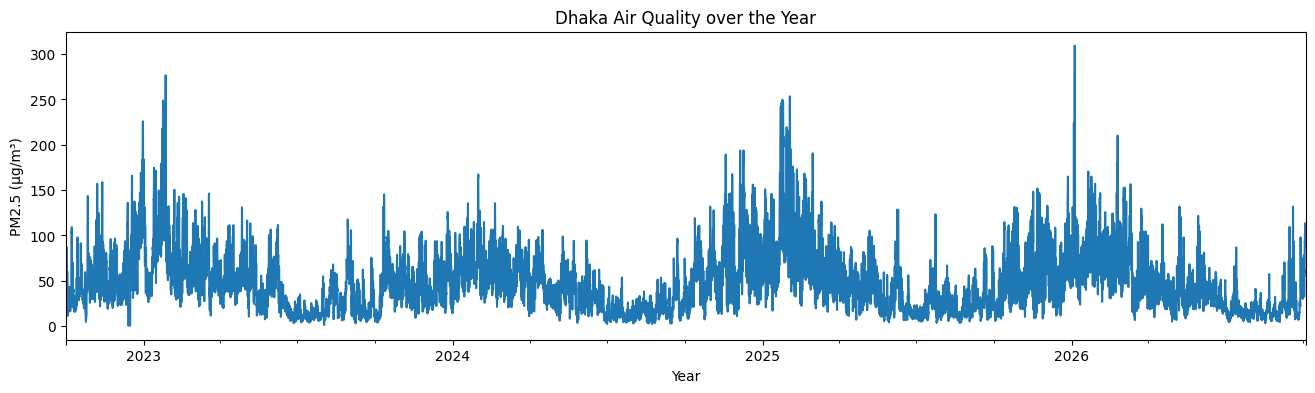

In [18]:
# Year-wise
df['pm2_5'].plot(figsize=(16,4), title="Dhaka Air Quality over the Year")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Year")
plt.show()

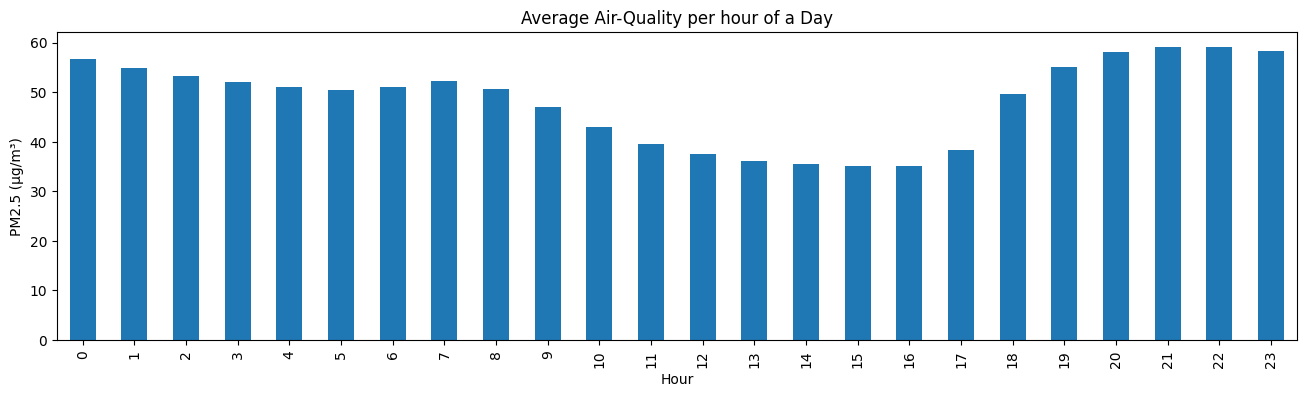

In [24]:
# An average day
hourly_avg= df.groupby(df.index.hour)["pm2_5"].mean()
hourly_avg.plot(figsize=(16,4), kind= "bar", title= "Average Air-Quality per hour of a Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

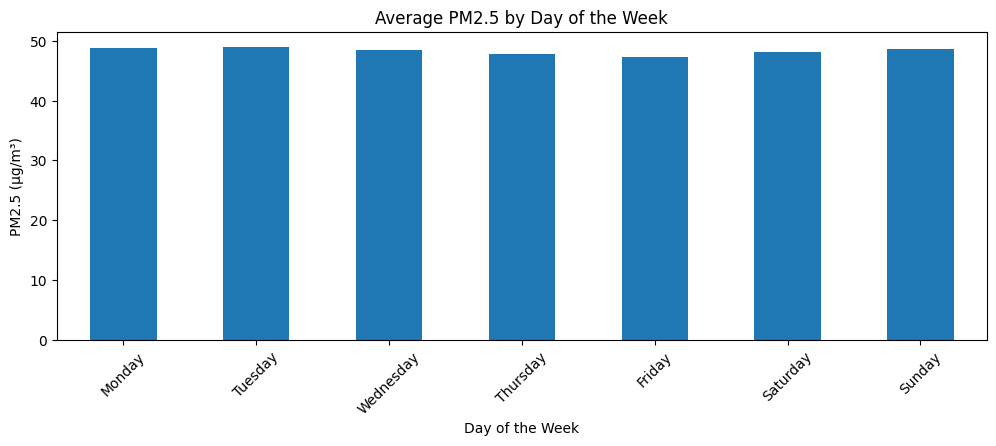

In [26]:
# Average PM2.5 for each day of the week
weekly_avg = df.groupby(df.index.day_name())["pm2_5"].mean()

# Put days in correct order
days_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekly_avg = weekly_avg.reindex(days_order)

# Plot
weekly_avg.plot(
    figsize=(12, 4),
    kind="bar",
    title="Average PM2.5 by Day of the Week"
)

plt.xlabel("Day of the Week")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.show()

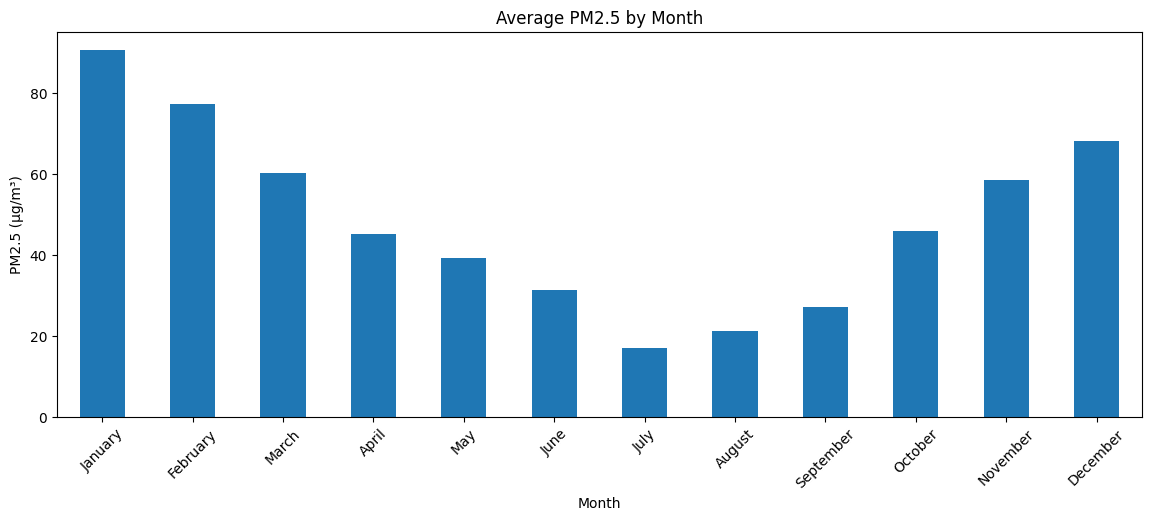

In [27]:
# Average PM2.5 for each month
monthly_avg = df.groupby(df.index.month_name())["pm2_5"].mean()

# Put months in correct chronological order
months_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_avg = monthly_avg.reindex(months_order)

# Plot
monthly_avg.plot(
    figsize=(14, 5),
    kind="bar",
    title="Average PM2.5 by Month"
)

plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.show()

### Monthly PM2.5 Pattern

- The monthly average PM2.5 shows a clear seasonal pattern. **January has the highest average PM2.5 concentration (around 90 µg/m³)**, followed by February and December. PM2.5 gradually decreases from March through June and reaches its **lowest level in July (around 17 µg/m³)**. Concentrations then increase gradually from August through December.

- Overall, the results indicate that **PM2.5 concentrations are generally higher during the winter months (November–February) and lower during the monsoon/summer period (June–September)**. This strong seasonal pattern suggests that **month or season may be an important feature for the PM2.5 forecasting model**.